# Sub graph implementation
- Problem Statement: When a user asks a question to LLM and the LLM responds it in English, this inturn is passed into another sub graph which is responsible for translation, and then the translated output is generated 
- Workflow
    - START -> Q&A -> Translation -> END
    - This workflow will maintain a state say state1
- For Q&A there will be an LLM
- The translation node will invoke another subgraph which is responsible for translation
- START -> Translate -> End 
    - This workflow will maintain another state say state2

# Sub graph implementation using method 1 i.e. invoking a subgraph from a node

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq


/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Defining the state for the translation sub graph
- The input to this graph will be an english text 
- The output will be the translated text

In [3]:
class state2(TypedDict):
    input_text: str
    translated_text: str
    

# Defining the function

In [4]:
def translate(state: state2):
    prompt = f"Translate the following text: {state["input_text"]} to Kannada"

    translated_text = model.invoke(prompt).content

    return {"translated_text": translated_text}

# Building the sub graph

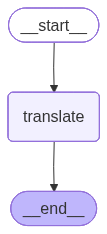

In [5]:
from gettext import translation


translation_subgraph = StateGraph(state2)

# Adding nodes
translation_subgraph.add_node("translate", translate)

# Adding edges
translation_subgraph.add_edge(START, "translate")
translation_subgraph.add_edge("translate", END)

# Compiling the graph
translation_workflow = translation_subgraph.compile()
translation_workflow

# Defining the state of the parent graph
- The state will have the information about the question asked by the user, response and the translated text

In [6]:
class state1(TypedDict):
    question: str
    response: str
    translated_text_response: str

# Defining the function for getting LLM Response
- Under the parent graph there are 4 nodes
    - START
    - END
    - get_response
    - translate_text: This will inturn call the translation_workflow which is a subgraph
- The value of result will contain the full state of the subgraph i.e. input_text and translated_text


In [7]:
def get_response(state: state1):
    prompt = f"Answer the given question: {state["question"]}"
    response = model.invoke(prompt).content

    return {"response": response}


def translate_text(state: state1):
    result = translation_workflow.invoke({"input_text": state["response"]})

    return {"translated_text_response": result["translated_text"]}

# Building the graph

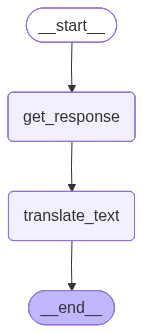

In [8]:
graph = StateGraph(state1)

# Adding nodes
graph.add_node("get_response", get_response)
graph.add_node("translate_text",translate_text)

# Adding edges
graph.add_edge(START, "get_response")
graph.add_edge("get_response", "translate_text")
graph.add_edge("translate_text", END)

# Compile
workflow = graph.compile()

workflow


In [9]:
workflow.invoke({"question": "What is Langgraph?"})

{'question': 'What is Langgraph?',
 'response': '<think>\nOkay, so I need to figure out what LangGraph is. Let me start by breaking down the term. "Lang" might stand for language, and "Graph" likely refers to a data structure used to represent relationships between entities. So, putting them together, LangGraph could be a framework or tool that uses graph structures for language-related tasks.\n\nFirst, I should check if there\'s any existing knowledge about LangGraph. I know that in the field of artificial intelligence, especially natural language processing (NLP), there are various frameworks and libraries. For example, TensorFlow, PyTorch, Hugging Face\'s Transformers, and others. But LangGraph isn\'t one I\'m immediately familiar with, so it might be a newer or less well-known project.\n\nI can start by searching online. Maybe there\'s a GitHub repository, a documentation page, or a research paper. Let me think about possible sources. If I were to search, I might look for "LangGrap


- In this the sub graph and the parent graphs are maintaining their own states

# Sub graph implementation using method 2 a graph has a node as its sub graph

- But if you want to invoke a sub graph within the parent then these are the changes to be incorporated
- There will be a shared state and no 2 states present 
```bash
class state1(TypedDict):
    question: star
    answer: str
    translated_text: str

```
- Instead of passing state2 for the translation subgraph state1 is only passed
- The parent graph will not contain a defination for translate_text
- The parent graph will directly add the subgraph i.e. translation_workflow as a node
```bash
graph = StateGraph(state1)

graph.add_node("get_response", get_response)
graph.add_node("translate", translation_workflow) # Subgraph is used as a node

graph.add_edge(START, "get_response")
graph.add_edge("get_response", "translate")
graph.add_edge("translate", END)
```